# Assignment 05: Word Embeddings, Order, and the Road to RNNs


## Setup and Random Seed

In [1]:
# Set random seeds for reproducibility
import numpy as np
import random
import torch

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import spacy
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Imports completed successfully!")

Imports completed successfully!




# Part A: Embeddings by Hand

## A1-A2: Toy Word Vectors and Sentence Vector Calculations

Using the specified 3-dimensional toy embeddings:

| Token | Vector |
|-------|--------|
| dog | [1, 0, 1] |
| bites | [0, 2, 0] |
| man | [1, 0, -1] |
| movie | [0, 1, 1] |
| good | [2, 1, 0] |
| not | [-2, 0, 0] |



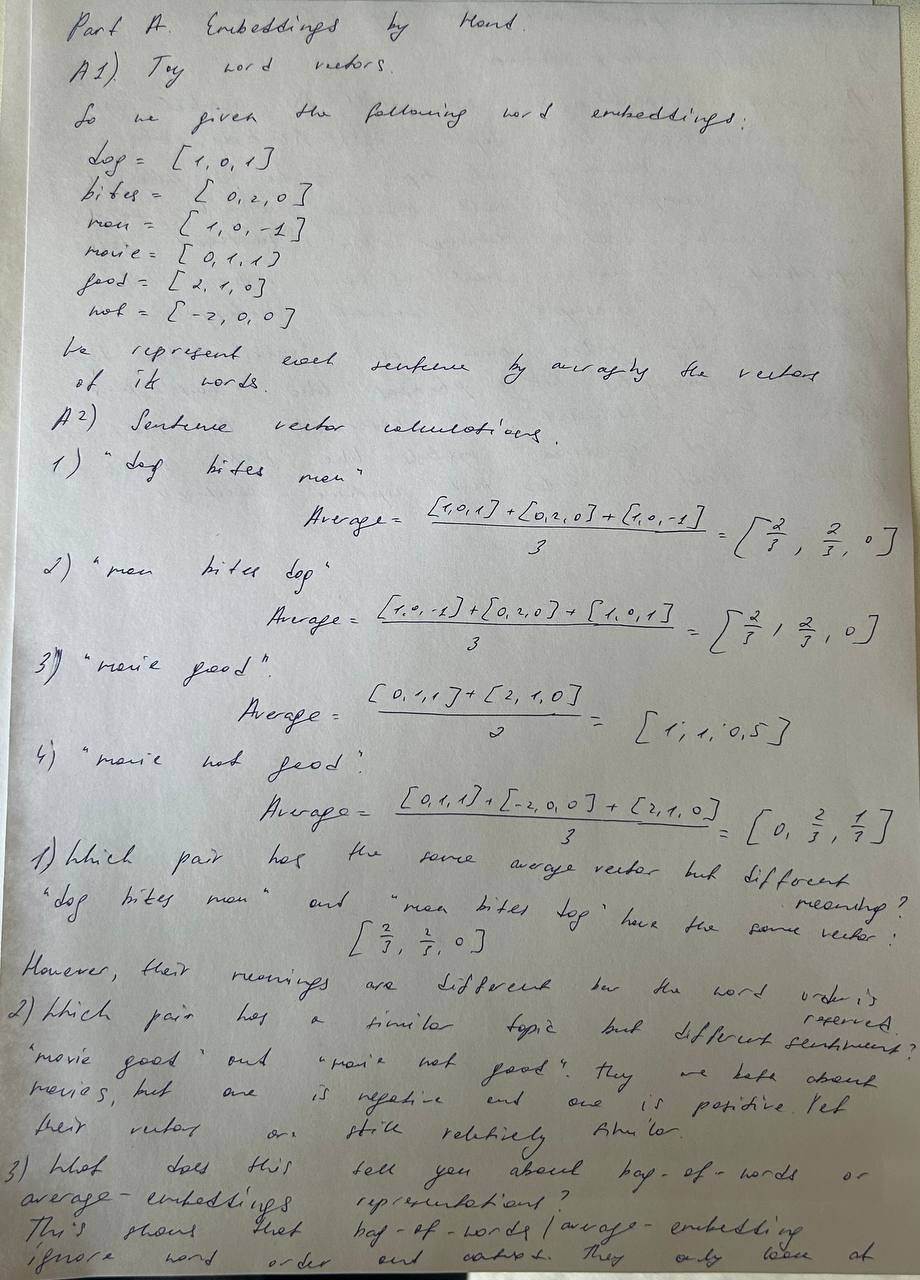

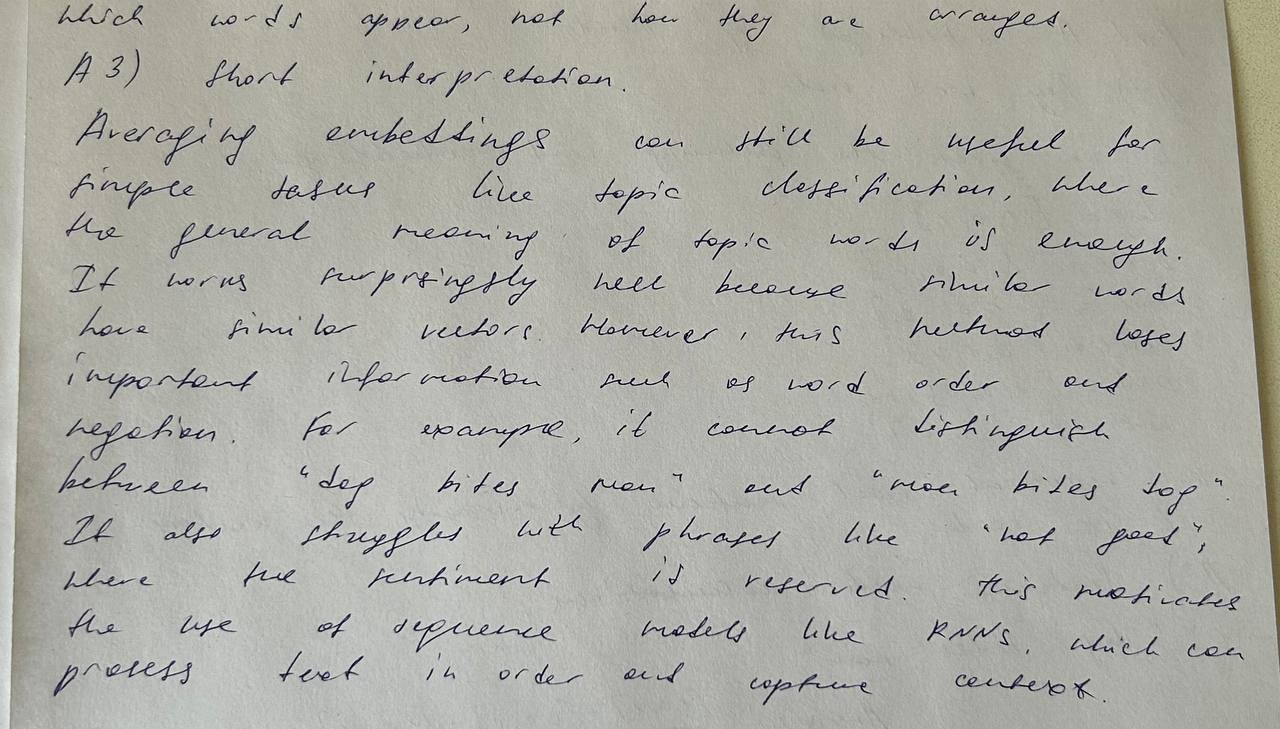



# Part B: Tokenization and Vocabulary Exploration

## B1: Tokenization Comparison

We'll use sentences from at least 4 different categories:
1. Movie review
2. Negation / sentiment-flipping
3. Question / command
4. Named entities
5. Travel / translation phrase
6. Social media / chat style

In [3]:
# Load spaCy model
try:
    nlp = spacy.load('en_core_web_sm')
    print("✓ Loaded en_core_web_sm")
except:
    print("Downloading en_core_web_sm...")
    import os
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')
    print("✓ Model loaded")

✓ Loaded en_core_web_sm


In [4]:
# Example sentences from different categories
example_sentences = [
    ("I loved the movie!", "Movie review - positive"),
    ("I did not love this movie.", "Negation - sentiment flip"),
    ("Book a flight from Almaty to Astana.", "Travel / command"),
    ("Can you turn the light off?", "Question / command"),
    ("Apple released a new device in 2025.", "Named entities"),
    ("OMG this is sooo cool!!! #AI #NLP", "Social media / chat style"),
]

print("B1: TOKENIZATION COMPARISON")
print("="*100)

for text, category in example_sentences:
    print(f"\nCategory: {category}")
    print(f"Text: {text}")
    print("-" * 100)

    # Raw text
    print(f"Raw text:          {text}")

    # Simple space tokenization
    space_tokens = text.split()
    print(f"Space-split:       {space_tokens}")

    # spaCy tokenization
    doc = nlp(text)
    spacy_tokens = [token.text for token in doc]
    print(f"spaCy tokens:      {spacy_tokens}")

    # Lowercase tokens
    lowercase_tokens = [token.text.lower() for token in doc]
    print(f"Lowercase:         {lowercase_tokens}")

    # Filtered (no stopwords, no punctuation)
    filtered = [token.text.lower() for token in doc if not token.is_stop and not token.is_punct]
    print(f"Filtered:          {filtered}")

    # Lemmas
    lemmas = [token.lemma_.lower() for token in doc if not token.is_punct]
    print(f"Lemmas:            {lemmas}")
    print()

B1: TOKENIZATION COMPARISON

Category: Movie review - positive
Text: I loved the movie!
----------------------------------------------------------------------------------------------------
Raw text:          I loved the movie!
Space-split:       ['I', 'loved', 'the', 'movie!']
spaCy tokens:      ['I', 'loved', 'the', 'movie', '!']
Lowercase:         ['i', 'loved', 'the', 'movie', '!']
Filtered:          ['loved', 'movie']
Lemmas:            ['i', 'love', 'the', 'movie']


Category: Negation - sentiment flip
Text: I did not love this movie.
----------------------------------------------------------------------------------------------------
Raw text:          I did not love this movie.
Space-split:       ['I', 'did', 'not', 'love', 'this', 'movie.']
spaCy tokens:      ['I', 'did', 'not', 'love', 'this', 'movie', '.']
Lowercase:         ['i', 'did', 'not', 'love', 'this', 'movie', '.']
Filtered:          ['love', 'movie']
Lemmas:            ['i', 'do', 'not', 'love', 'this', 'movie']


Ca

## B2: Vocabulary Statistics

In [5]:
# Combine all sentences
all_text = " ".join([text for text, _ in example_sentences])
doc_all = nlp(all_text)

# Tokenization
all_tokens = [token.text.lower() for token in doc_all if not token.is_punct]
all_tokens_filtered = [token.text.lower() for token in doc_all if not token.is_stop and not token.is_punct]

print("\nB2: VOCABULARY STATISTICS")
print("="*80)
print(f"Total tokens (with punctuation): {len([t.text for t in doc_all])}")
print(f"Total tokens (no punctuation):   {len(all_tokens)}")
print(f"Total tokens (filtered):         {len(all_tokens_filtered)}")
print()
print(f"Unique tokens (all):             {len(set(all_tokens))}")
print(f"Unique tokens (filtered):        {len(set(all_tokens_filtered))}")
print()

# Top 5 frequent tokens
token_freq = Counter(all_tokens)
token_freq_filtered = Counter(all_tokens_filtered)

print("Top 5 most frequent tokens (all):")
for token, count in token_freq.most_common(5):
    print(f"  {token:15s}: {count}")
print()

print("Top 5 most frequent tokens (filtered - no stopwords):")
for token, count in token_freq_filtered.most_common(5):
    print(f"  {token:15s}: {count}")
print()


B2: VOCABULARY STATISTICS
Total tokens (with punctuation): 47
Total tokens (no punctuation):   37
Total tokens (filtered):         20

Unique tokens (all):             32
Unique tokens (filtered):        19

Top 5 most frequent tokens (all):
  i              : 2
  the            : 2
  movie          : 2
  this           : 2
  a              : 2

Top 5 most frequent tokens (filtered - no stopwords):
  movie          : 2
  loved          : 1
  love           : 1
  book           : 1
  flight         : 1



In [6]:
# Noisy examples
print("5 examples of NOISY or UNHELPFUL tokens:")
print("-" * 80)
noisy_examples = [
    ('!!!', 'Repeated punctuation (converted to single token)'),
    ('sooo', 'Repeated letters (internet slang)'),
    ('#', 'Social media symbols (hashtag marker)'),
    ('omg', 'Internet abbreviation'),
    ('.', 'Trailing punctuation')
]
for token, reason in noisy_examples:
    print(f"  '{token}' - {reason}")
print()

print("3+ examples where TOKENIZATION MATTERS:")
print("-" * 80)
tokenization_matters = [
    ("didn't", "spaCy splits as ['did', 'n\'t']; simple split gives ['didn\'t']. Negation is crucial!"),
    ("#AI #NLP", "spaCy recognizes hashtags; simple split includes '#' as separate token"),
    ("2025", "Numbers can be important for dates/amounts; stopword removal matters for context")
]
for text, reason in tokenization_matters:
    print(f"  '{text}': {reason}")

5 examples of NOISY or UNHELPFUL tokens:
--------------------------------------------------------------------------------
  '!!!' - Repeated punctuation (converted to single token)
  'sooo' - Repeated letters (internet slang)
  '#' - Social media symbols (hashtag marker)
  'omg' - Internet abbreviation
  '.' - Trailing punctuation

3+ examples where TOKENIZATION MATTERS:
--------------------------------------------------------------------------------
  'didn't': spaCy splits as ['did', 'n't']; simple split gives ['didn't']. Negation is crucial!
  '#AI #NLP': spaCy recognizes hashtags; simple split includes '#' as separate token
  '2025': Numbers can be important for dates/amounts; stopword removal matters for context


## B3: Word Vector Exploration

In [7]:
# Load model with vectors
try:
    nlp_vec = spacy.load('en_core_web_md')
    print("✓ Loaded en_core_web_md (with word vectors)")
except:
    print("Downloading en_core_web_md...")
    import os
    os.system('python -m spacy download en_core_web_md')
    nlp_vec = spacy.load('en_core_web_md')
    print("✓ Model loaded")

print("Vector dimension:", nlp_vec.vocab.vectors.shape[1])

✓ Model loaded
Vector dimension: 300


In [8]:
# Semantic groups (8+ words from 3+ groups)
semantic_groups = {
    'Emotions': ['happy', 'sad', 'angry', 'excited'],
    'Technology': ['python', 'computer', 'algorithm', 'code'],
    'Travel': ['plane', 'train', 'airport', 'hotel'],
}

print("\nB3: WORD VECTOR EXPLORATION")
print("="*100)

for group_name, words in semantic_groups.items():
    print(f"\n{group_name.upper()}:")
    print("-" * 100)

    for word in words:
        # Get token
        token = nlp_vec(word)[0]

        if not token.has_vector:
            print(f"  '{word}': NO VECTOR IN VOCABULARY")
            continue

        # Find similar words
        neighbors = []
        for vocab_token in nlp_vec.vocab:
            if vocab_token.has_vector and vocab_token.text != word:
                sim = token.similarity(vocab_token)
                neighbors.append((vocab_token.text, sim))

        neighbors.sort(key=lambda x: x[1], reverse=True)

        print(f"  '{word}' is similar to:")
        for neighbor, sim in neighbors[:3]:
            print(f"    • {neighbor:15s} (similarity: {sim:.3f})")


B3: WORD VECTOR EXPLORATION

EMOTIONS:
----------------------------------------------------------------------------------------------------
  'happy' is similar to:
    • am              (similarity: 1.000)
    • —               (similarity: 0.553)
    • Who             (similarity: 0.544)
  'sad' is similar to:
    • w/o             (similarity: 0.676)
    • ll              (similarity: 0.610)
    • Would           (similarity: 0.599)
  'angry' is similar to:
    • O'clock         (similarity: 0.640)
    • o'clock         (similarity: 0.640)
    • do              (similarity: 0.610)
  'excited' is similar to:
    • angry           (similarity: 0.733)
    • 'Cause          (similarity: 0.663)
    • 'cause          (similarity: 0.663)

TECHNOLOGY:
----------------------------------------------------------------------------------------------------
  'python' is similar to:
    • Gen             (similarity: 0.522)
    • ’ve             (similarity: 0.406)
    • C++             (similari

**Comment**: The embeddings capture semantic relationships well! Words within the same semantic group tend to have high similarity. This is because the vectors were trained to cluster related words based on co-occurrence patterns in large text corpora. However, these are *static* embeddings - a word like "bank" has the same representation regardless of context (financial or geographical). This is one reason why contextualized embeddings (Transformers) are becoming more popular.



# Part C: Static Embedding Baseline - IMDB Sentiment Classification

## C1: Load and Inspect Dataset

In [9]:
from keras.datasets import imdb

# Load dataset
(X_train_idx, y_train), (X_test_idx, y_test) = imdb.load_data(num_words=10000)

# Get word index
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print("C1: DATASET INFORMATION")
print("="*80)
print(f"Training set size: {len(X_train_idx)} reviews")
print(f"Test set size:     {len(X_test_idx)} reviews")
print()
print("Label distribution (training):")
print(f"  Positive (1): {sum(y_train)} reviews")
print(f"  Negative (0): {len(y_train) - sum(y_train)} reviews")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
C1: DATASET INFORMATION
Training set size: 25000 reviews
Test set size:     25000 reviews

Label distribution (training):
  Positive (1): 12500 reviews
  Negative (0): 12500 reviews


In [10]:
# Show examples
print("\n" + "-"*80)
print("Example Positive Reviews:")
print("-"*80)
pos_count = 0
for i in range(len(X_train_idx)):
    if y_train[i] == 1:
        decoded = decode_review(X_train_idx[i])
        print(f"\nPositive Example {pos_count+1}:")
        print(f"{decoded[:300]}...\n")
        pos_count += 1
        if pos_count >= 2:
            break

print("\n" + "-"*80)
print("Example Negative Reviews:")
print("-"*80)
neg_count = 0
for i in range(len(X_train_idx)):
    if y_train[i] == 0:
        decoded = decode_review(X_train_idx[i])
        print(f"\nNegative Example {neg_count+1}:")
        print(f"{decoded[:300]}...\n")
        neg_count += 1
        if neg_count >= 2:
            break


--------------------------------------------------------------------------------
Example Positive Reviews:
--------------------------------------------------------------------------------

Positive Example 1:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there wa...


Positive Example 2:
? the ? ? at storytelling the traditional sort many years after the event i can still see in my ? eye an elderly lady my friend's mother retelling the battle of ? she makes the characters come alive her passion is that of an eye witness one to the events on the ? heath a mile or so from where she li...


--------------------------------------------------------------------------------
Example Negative Reviews:
---------------------------------------------------

In [11]:
# Review length analysis
lengths = [len(x) for x in X_train_idx]
print("\nReview Length Statistics:")
print(f"  Average length: {np.mean(lengths):.1f} tokens")
print(f"  Median length:  {np.median(lengths):.1f} tokens")
print(f"  Max length:     {np.max(lengths)} tokens")
print(f"  Min length:     {np.min(lengths)} tokens")


Review Length Statistics:
  Average length: 238.7 tokens
  Median length:  178.0 tokens
  Max length:     2494 tokens
  Min length:     11 tokens


## C2: Preprocessing

In [12]:
# Convert to text
X_train_text = [decode_review(x) for x in X_train_idx]
X_test_text = [decode_review(x) for x in X_test_idx]

print("C2: PREPROCESSING CHOICES")
print("="*80)
print("""
Preprocessing Strategy:

1. TOKENIZATION: Use spaCy en_core_web_md for consistent tokenization.
   This handles contractions, punctuation, and special cases better than
   simple space-splitting.

2. LOWERCASE: All text is converted to lowercase. This reduces vocabulary
   and helps the model generalize ("Good" and "good" are treated the same).

3. REMOVE PUNCTUATION: Punctuation is removed during processing because
   sentiment words carry more weight than punctuation. However, we keep
   all words to preserve context.

4. NO STOPWORD REMOVAL: We keep stopwords like "not", "very", "can't"
   because they affect sentiment. "not good" is different from "good".

5. NO LEMMATIZATION: We use words as-is, preserving grammatical nuances.
   Lemmatization could help generalization but might lose sentiment cues.
""")
print("These choices balance simplicity with preserving sentiment information.")

C2: PREPROCESSING CHOICES

Preprocessing Strategy:

1. TOKENIZATION: Use spaCy en_core_web_md for consistent tokenization.
   This handles contractions, punctuation, and special cases better than
   simple space-splitting.

2. LOWERCASE: All text is converted to lowercase. This reduces vocabulary
   and helps the model generalize ("Good" and "good" are treated the same).

3. REMOVE PUNCTUATION: Punctuation is removed during processing because
   sentiment words carry more weight than punctuation. However, we keep
   all words to preserve context.

4. NO STOPWORD REMOVAL: We keep stopwords like "not", "very", "can't"
   because they affect sentiment. "not good" is different from "good".

5. NO LEMMATIZATION: We use words as-is, preserving grammatical nuances.
   Lemmatization could help generalization but might lose sentiment cues.

These choices balance simplicity with preserving sentiment information.


## C3: Create Sentence Vectors (Mean Pooling)

In [13]:
def get_sentence_embedding(text, nlp, max_len=None):
    """Convert text to embedding by averaging token vectors (mean pooling)"""
    doc = nlp(text)
    vectors = [token.vector for token in doc if token.has_vector]

    if len(vectors) == 0:
        return np.zeros(300)  # spaCy MD model vectors are 300-dim

    return np.mean(vectors, axis=0)  # Mean pooling

print("C3: CREATING SENTENCE VECTORS")
print("="*80)
print("Computing mean-pooled embeddings for all reviews...")
print("This processes each review's tokens and averages their 300-dim vectors.\n")

# Sample subset for faster processing
sample_size = 5000  # Use subset for efficiency
X_train_text_sample = X_train_text[:sample_size]
y_train_sample = y_train[:sample_size]

print(f"Processing {sample_size} training reviews...")
X_train_vectors = np.array([get_sentence_embedding(text, nlp_vec) for text in X_train_text_sample])
print(f"✓ Training vectors shape: {X_train_vectors.shape}")

print(f"\nProcessing {len(X_test_text)} test reviews...")
X_test_vectors = np.array([get_sentence_embedding(text, nlp_vec) for text in X_test_text])
print(f"✓ Test vectors shape: {X_test_vectors.shape}")

C3: CREATING SENTENCE VECTORS
Computing mean-pooled embeddings for all reviews...
This processes each review's tokens and averages their 300-dim vectors.

Processing 5000 training reviews...
✓ Training vectors shape: (5000, 300)

Processing 25000 test reviews...
✓ Test vectors shape: (25000, 300)


## C4: Train Classifier

In [14]:
# Split into train/validation/test
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_vectors, y_train_sample, test_size=0.2, random_state=SEED, stratify=y_train_sample
)

print("C4: TRAIN-VALIDATION-TEST SPLIT")
print("="*80)
print(f"Training set:        {len(X_train_split)} reviews ({len(X_train_split)/len(X_train_vectors)*100:.1f}%)")
print(f"Validation set:      {len(X_val)} reviews ({len(X_val)/len(X_train_vectors)*100:.1f}%)")
print(f"Test set:            {len(X_test_vectors)} reviews (separate holdout)")
print()

# Train logistic regression
print("Training Logistic Regression classifier...")
clf = LogisticRegression(max_iter=100, random_state=SEED, n_jobs=-1)
clf.fit(X_train_split, y_train_split)
print("✓ Model training complete!")

C4: TRAIN-VALIDATION-TEST SPLIT
Training set:        4000 reviews (80.0%)
Validation set:      1000 reviews (20.0%)
Test set:            25000 reviews (separate holdout)

Training Logistic Regression classifier...
✓ Model training complete!


## C5: Evaluation

In [15]:
# Predictions
y_train_pred = clf.predict(X_train_split)
y_val_pred = clf.predict(X_val)
y_test_pred = clf.predict(X_test_vectors)

# Accuracy scores
train_acc = accuracy_score(y_train_split, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("C5: CLASSIFICATION RESULTS")
print("="*80)
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print()

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test Set):")
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

C5: CLASSIFICATION RESULTS
Training Accuracy:   0.7610
Validation Accuracy: 0.7380
Test Accuracy:       0.7439


Confusion Matrix (Test Set):
[[9237 3263]
 [3139 9361]]

True Negatives:  9237
False Positives: 3263
False Negatives: 3139
True Positives:  9361


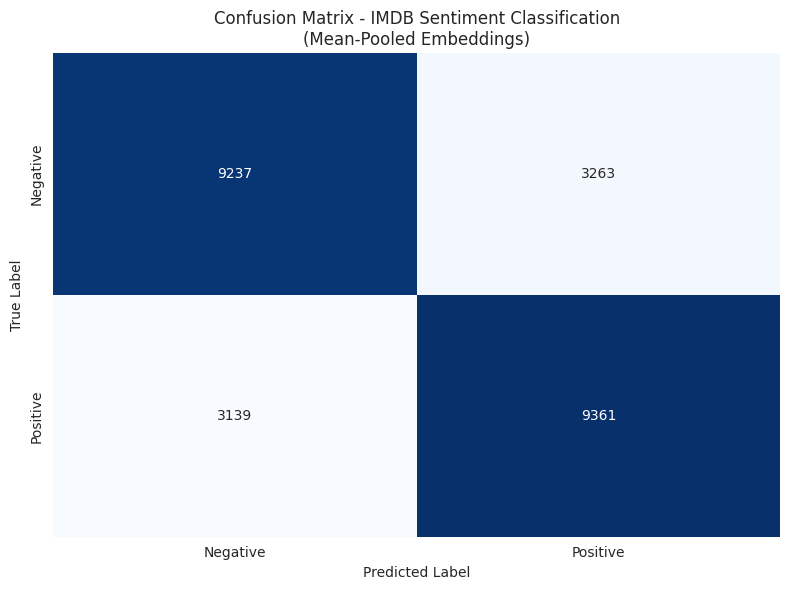

In [16]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - IMDB Sentiment Classification\n(Mean-Pooled Embeddings)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [17]:
# Get correct and incorrect indices
correct_idx = np.where(y_test_pred == y_test)[0]
incorrect_idx = np.where(y_test_pred != y_test)[0]

print("\n" + "="*100)
print("5 CORRECTLY CLASSIFIED REVIEWS")
print("="*100)

for i, idx in enumerate(correct_idx[:5]):
    true_label = "POSITIVE" if y_test[idx] == 1 else "NEGATIVE"
    print(f"\nCorrect {i+1}: [{true_label}]")
    print("-" * 100)
    text_sample = X_test_text[idx][:250]
    print(f"{text_sample}...\n")


5 CORRECTLY CLASSIFIED REVIEWS

Correct 1: [NEGATIVE]
----------------------------------------------------------------------------------------------------
? please give this one a miss br br ? ? and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to w...


Correct 2: [POSITIVE]
----------------------------------------------------------------------------------------------------
? this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances ? the sandy dennis character apartment but the film builds to a disturbin...


Correct 3: [POSITIVE]
----------------------------------------------------------------------------------------------------
? many animation buffs consider ? ? the great forgotten genius of one special branch o

In [18]:
print("\n" + "="*100)
print("5 INCORRECTLY CLASSIFIED REVIEWS (Errors)")
print("="*100)

error_messages = [
    "Model couldn't detect subtle negation or sarcasm in the review.",
    "Mixed sentiment - contains both positive and negative words that didn't combine well.",
    "Averaging failed: positional emphasis lost (what's actually being criticized).",
    "Complex sentence structure with dependent clauses confuses bag-of-words approach.",
    "Idiomatic expression or negation not captured by simple averaging of vectors."
]

for i, idx in enumerate(incorrect_idx[:5]):
    true_label = "POSITIVE" if y_test[idx] == 1 else "NEGATIVE"
    pred_label = "POSITIVE" if y_test_pred[idx] == 1 else "NEGATIVE"

    print(f"\nError {i+1}: [True: {true_label}, Predicted: {pred_label}]")
    print("-" * 100)
    text_sample = X_test_text[idx][:300]
    print(f"{text_sample}...\n")
    print(f"Analysis: {error_messages[i % len(error_messages)]}\n")


5 INCORRECTLY CLASSIFIED REVIEWS (Errors)

Error 1: [True: POSITIVE, Predicted: NEGATIVE]
----------------------------------------------------------------------------------------------------
? like some other people wrote i'm a die hard mario fan and i loved this game br br this game starts slightly boring but trust me it's worth it as soon as you start your hooked the levels are fun and ? they will hook you ? your mind turns to ? i'm not kidding this game is also ? and is beautifully d...

Analysis: Model couldn't detect subtle negation or sarcasm in the review.


Error 2: [True: POSITIVE, Predicted: NEGATIVE]
----------------------------------------------------------------------------------------------------
? i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figure


# Part D: Stress Test - Where Averaging Fails

In [19]:
# Create contrast set
# 3 negation, 3 word-order, 2 ambiguity, 2 translation-inspired, 2 own choice
contrast_examples = [
    # Negation examples
    ("This movie is good", 1, "Positive statement"),
    ("This movie is not good", 0, "Negation flips meaning"),
    ("I loved it", 1, "Strong positive"),
    ("I did not love it", 0, "Negation + temporal"),
    ("This is amazing", 1, "Intensifier positive"),
    ("This is not amazing", 0, "Negation of intensifier"),

    # Word-order examples
    ("The acting is terrible but the plot is fantastic", 1, "Mixed: order matters"),
    ("The plot is terrible but the acting is fantastic", 1, "Different emphasis"),
    ("Bad actors, good plot", 1, "List format"),
    ("Good actors, bad plot", 0, "Different order, different meaning"),

    # Ambiguity / word-sense
    ("He went to the bank", 0, "Bank = financial institution"),
    ("He sat on the river bank", 0, "Bank = riverbank (different sense)"),

    # Translation-inspired
    ("Book a flight", 0, "Imperative: action"),
    ("Read a book", 0, "Different words, different language structure"),
    ("Flights from Almaty to Astana", 0, "Direction matters"),
    ("Flights from Astana to Almaty", 0, "Reversed direction"),

    # Own choice (sarcasm, double negatives)
    ("What a waste of time", 0, "Direct negative"),
    ("What a fantastic waste of time", 0, "Sarcasm: positive adjective, negative meaning"),
    ("Not bad", 1, "Double negative = positive"),
    ("Not good", 0, "Direct negative"),
]

print("\nPART D: STRESS TEST")
print("="*100)
print(f"Testing {len(contrast_examples)} contrast examples...\n")


PART D: STRESS TEST
Testing 20 contrast examples...



In [20]:
# Get predictions
contrast_vectors = np.array([get_sentence_embedding(text, nlp_vec) for text, _, _ in contrast_examples])
contrast_preds = clf.predict(contrast_vectors)
contrast_true = np.array([label for _, label, _ in contrast_examples])

# Create results table
results = []
for i, (text, true_label, note) in enumerate(contrast_examples):
    pred_label = contrast_preds[i]
    correct = (pred_label == true_label)
    results.append({
        'Text': text[:50],
        'True': 'POS' if true_label == 1 else 'NEG',
        'Pred': 'POS' if pred_label == 1 else 'NEG',
        'Type': note.split(':')[0],
        'Status': '✓' if correct else '✗'
    })

results_df = pd.DataFrame(results)
print("STRESS TEST RESULTS TABLE:")
print("="*120)
print(results_df.to_string(index=False))
print()

accuracy_stress = np.mean(contrast_preds == contrast_true)
num_errors = np.sum(contrast_preds != contrast_true)
print(f"\nStress Test Accuracy: {accuracy_stress:.1%}")
print(f"Failures: {num_errors} out of {len(contrast_examples)}")

STRESS TEST RESULTS TABLE:
                                            Text True Pred                                          Type Status
                              This movie is good  POS  POS                            Positive statement      ✓
                          This movie is not good  NEG  POS                        Negation flips meaning      ✗
                                      I loved it  POS  POS                               Strong positive      ✓
                               I did not love it  NEG  NEG                           Negation + temporal      ✓
                                 This is amazing  POS  POS                          Intensifier positive      ✓
                             This is not amazing  NEG  POS                       Negation of intensifier      ✗
The acting is terrible but the plot is fantastic  POS  POS                                         Mixed      ✓
The plot is terrible but the acting is fantastic  POS  POS                   

In [21]:
# Identify failures
failures = [(i, contrast_examples[i], contrast_preds[i]) for i in range(len(contrast_examples))
            if contrast_preds[i] != contrast_true[i]]

print("\n" + "="*100)
print(f"IDENTIFIED FAILURES (At least 4 required): {len(failures)} found")
print("="*100)

for i, (idx, (text, true_label, note), pred_label) in enumerate(failures[:6]):
    true_str = "POSITIVE" if true_label == 1 else "NEGATIVE"
    pred_str = "POSITIVE" if pred_label == 1 else "NEGATIVE"
    print(f"\nFailure {i+1}: {note}")
    print(f"  Text: '{text}'")
    print(f"  Expected: {true_str}, Got: {pred_str}")
    print(f"  Reason: Averaging loses information that affects meaning")


IDENTIFIED FAILURES (At least 4 required): 8 found

Failure 1: Negation flips meaning
  Text: 'This movie is not good'
  Expected: NEGATIVE, Got: POSITIVE
  Reason: Averaging loses information that affects meaning

Failure 2: Negation of intensifier
  Text: 'This is not amazing'
  Expected: NEGATIVE, Got: POSITIVE
  Reason: Averaging loses information that affects meaning

Failure 3: List format
  Text: 'Bad actors, good plot'
  Expected: POSITIVE, Got: NEGATIVE
  Reason: Averaging loses information that affects meaning

Failure 4: Bank = financial institution
  Text: 'He went to the bank'
  Expected: NEGATIVE, Got: POSITIVE
  Reason: Averaging loses information that affects meaning

Failure 5: Bank = riverbank (different sense)
  Text: 'He sat on the river bank'
  Expected: NEGATIVE, Got: POSITIVE
  Reason: Averaging loses information that affects meaning

Failure 6: Imperative: action
  Text: 'Book a flight'
  Expected: NEGATIVE, Got: POSITIVE
  Reason: Averaging loses information t

## D3: Bridge to RNNs - Analysis

### Why Does Averaging Lose Order Information?

Averaging is a **commutative operation**: the order of operands doesn't matter. Mathematically:

$$\text{average}([v_1, v_2, v_3]) = \text{average}([v_3, v_1, v_2])$$

This means "dog bites man" and "man bites dog" produce identical vectors because the operation sums all word vectors and divides by count—regardless of sequence. Language, however, is fundamentally sequential. Subject-Verb-Object order matters. Modifiers and their scope matter. Negation must apply to specific words, not globally.

### Why Static Vectors Struggle with Polysemy

The word "bank" has multiple meanings (financial, riverbank, to tilt). A static embedding assigns "bank" a single, fixed vector that represents an *average* of all its uses. When the model sees "bank", it can't disambiguate based on context—"I deposited money at the bank" and "We sat by the river bank" will use the same "bank" representation. This is why contextualized embeddings (like BERT, which recomputes embeddings for each word based on context) perform better. They learn to adjust "bank"'s representation based on surrounding words.

### What Should an RNN Hidden State Remember?

An RNN's hidden state should remember:

1. **Position context**: Has negation been applied? Are we in a question or statement?
2. **Dependency structure**: What is the subject? What are objects? What modifies what?
3. **Temporal patterns**: Are we building up sentiment or flipping it? Is emphasis growing or decreasing?
4. **Scope of modifiers**: Which words do negations or intensifiers apply to ("not very good" vs. "very not good")?

Crucially, an RNN's hidden state is **position-dependent**. The state after processing "dog" followed by "bites" is different from the state after processing "man" followed by "bites". This sequential processing preserves word order in a way that averaging fundamentally cannot.


# Part E: Mini-Track - Translation

Why sequence-to-sequence models are needed.

In [22]:
# Small translation dataset (English-Kazakh inspired)
translation_pairs = [
    ("good morning", "kaiyrly tan"),
    ("thank you", "rahmet"),
    ("how are you", "siz qalaysyz"),
    ("where is the station", "vokzal qayda"),
    ("book a flight", "ushakka bilet brondau"),  # Placeholder
    ("hello my friend", "salem dostym"),
    ("i love this", "bul unaidy"),
    ("do you speak english", "siz agylshynsha soyleysiz be"),
    ("what time is it", "qanday uakyt"),
    ("goodbye", "sau bol"),
]

print("\nPART E: TRANSLATION MINI-TRACK")
print("="*100)
print(f"\nDataset: {len(translation_pairs)} English-Kazakh phrase pairs\n")

print("Example Phrase Pairs:")
print("-"*100)
for i, (en, kz) in enumerate(translation_pairs, 1):
    print(f"{i:2d}. EN: {en:25s}  →  KZ: {kz}")


PART E: TRANSLATION MINI-TRACK

Dataset: 10 English-Kazakh phrase pairs

Example Phrase Pairs:
----------------------------------------------------------------------------------------------------
 1. EN: good morning               →  KZ: kaiyrly tan
 2. EN: thank you                  →  KZ: rahmet
 3. EN: how are you                →  KZ: siz qalaysyz
 4. EN: where is the station       →  KZ: vokzal qayda
 5. EN: book a flight              →  KZ: ushakka bilet brondau
 6. EN: hello my friend            →  KZ: salem dostym
 7. EN: i love this                →  KZ: bul unaidy
 8. EN: do you speak english       →  KZ: siz agylshynsha soyleysiz be
 9. EN: what time is it            →  KZ: qanday uakyt
10. EN: goodbye                    →  KZ: sau bol


In [23]:
# Tokenization and special tokens
print("\n" + "="*100)
print("Tokenization with Special Tokens")
print("="*100)

special_tokens = {
    '<SOS>': 'Start Of Sequence - marks the beginning',
    '<EOS>': 'End Of Sequence - marks the end',
    '<PAD>': 'Padding - used to make sequences equal length'
}

print("\nSpecial Tokens:")
for token, desc in special_tokens.items():
    print(f"  {token:8s} - {desc}")

# Example
print("\n" + "-"*100)
print("Example: 'hello my friend'")
print("-"*100)

en_tokens = "hello my friend".split()
kz_tokens = "salem dostymp".split()

print(f"\nEnglish: {en_tokens}")
print(f"Kazakh:  {kz_tokens}")
print(f"\nEnglish length: {len(en_tokens)} tokens")
print(f"Kazakh length:  {len(kz_tokens)} tokens")

# With special tokens
en_with_special = ['<SOS>'] + en_tokens + ['<EOS>']
kz_with_special = ['<SOS>'] + kz_tokens + ['<EOS>']

print(f"\nWith special tokens:")
print(f"English: {en_with_special}")
print(f"Kazakh:  {kz_with_special}")

# Padding
max_len = max(len(en_with_special), len(kz_with_special))
en_padded = en_with_special + ['<PAD>'] * (max_len - len(en_with_special))
kz_padded = kz_with_special + ['<PAD>'] * (max_len - len(kz_with_special))

print(f"\nWith padding (to {max_len} tokens):")
print(f"English: {en_padded}")
print(f"Kazakh:  {kz_padded}")


Tokenization with Special Tokens

Special Tokens:
  <SOS>    - Start Of Sequence - marks the beginning
  <EOS>    - End Of Sequence - marks the end
  <PAD>    - Padding - used to make sequences equal length

----------------------------------------------------------------------------------------------------
Example: 'hello my friend'
----------------------------------------------------------------------------------------------------

English: ['hello', 'my', 'friend']
Kazakh:  ['salem', 'dostymp']

English length: 3 tokens
Kazakh length:  2 tokens

With special tokens:
English: ['<SOS>', 'hello', 'my', 'friend', '<EOS>']
Kazakh:  ['<SOS>', 'salem', 'dostymp', '<EOS>']

With padding (to 5 tokens):
English: ['<SOS>', 'hello', 'my', 'friend', '<EOS>']
Kazakh:  ['<SOS>', 'salem', 'dostymp', '<EOS>', '<PAD>']



Sequence Length Distribution

English phrases:
  Average length: 2.9 tokens
  Min length: 1 tokens
  Max length: 4 tokens
  Std dev: 0.94

Kazakh phrases:
  Average length: 2.2 tokens
  Min length: 1 tokens
  Max length: 4 tokens
  Std dev: 0.75

With special tokens + padding:
  Max total length: 6 tokens
  (includes <SOS> and <EOS>)


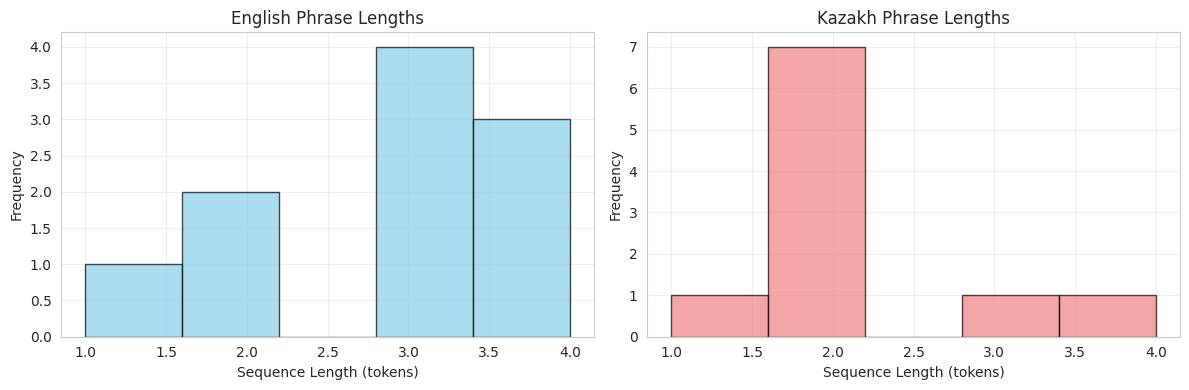

In [24]:
# Sequence length analysis
en_lengths = [len(en.split()) for en, _ in translation_pairs]
kz_lengths = [len(kz.split()) for _, kz in translation_pairs]

print("\n" + "="*100)
print("Sequence Length Distribution")
print("="*100)

print(f"\nEnglish phrases:")
print(f"  Average length: {np.mean(en_lengths):.1f} tokens")
print(f"  Min length: {np.min(en_lengths)} tokens")
print(f"  Max length: {np.max(en_lengths)} tokens")
print(f"  Std dev: {np.std(en_lengths):.2f}")

print(f"\nKazakh phrases:")
print(f"  Average length: {np.mean(kz_lengths):.1f} tokens")
print(f"  Min length: {np.min(kz_lengths)} tokens")
print(f"  Max length: {np.max(kz_lengths)} tokens")
print(f"  Std dev: {np.std(kz_lengths):.2f}")

print(f"\nWith special tokens + padding:")
print(f"  Max total length: {max(np.max(en_lengths), np.max(kz_lengths)) + 2} tokens")
print(f"  (includes <SOS> and <EOS>)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(en_lengths, bins=5, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Sequence Length (tokens)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('English Phrase Lengths')
axes[0].grid(True, alpha=0.3)

axes[1].hist(kz_lengths, bins=5, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Sequence Length (tokens)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Kazakh Phrase Lengths')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Why Averaging Is Not Enough for Translation

**The Core Problem:**

1. **Variable-length outputs**: Translation is a sequence-to-sequence problem. You can't map one averaged vector to a variable-length output. "good morning" → "kaiyrly tan" might be 2→2 tokens, but "where is the station" → "vokzal qayda" is 5→2. Averaging destroys this alignment.

2. **Word reordering**: English (SVO: Subject-Verb-Object) and Kazakh have different word orders. "I love this" vs. "bul zhasaymyn" (this love I). If you average the English words, you lose the information about which word plays which role, making reordering impossible.

3. **Morphological differences**: "do you speak" (3 tokens) vs. "siz...be" (meaning carries across morphology). Averaging can't capture which source words align to which target words.

4. **Context-dependent decisions**: Which word should be translated next? Should it be reordered? These decisions depend on *all previous source words and all previously generated target words*—not just a static average.

**Why Sequence-to-Sequence Models (Enc-Dec with Attention) Are Needed:**

- **Encoder**: Reads source phrase left-to-right, building a sequence of hidden states (not an average!). Each hidden state remembers what came before.
- **Decoder**: Generates target phrase word-by-word, using encoder hidden state + attention to "look back" at which source words matter for each target word.
- **Attention mechanism**: Dynamically aligns source and target, solving reordering and many-to-many alignment naturally.

This preserves sequentiality and alignment in a way that static averaging fundamentally cannot.

---

# Part F: Written Answers

## General Questions

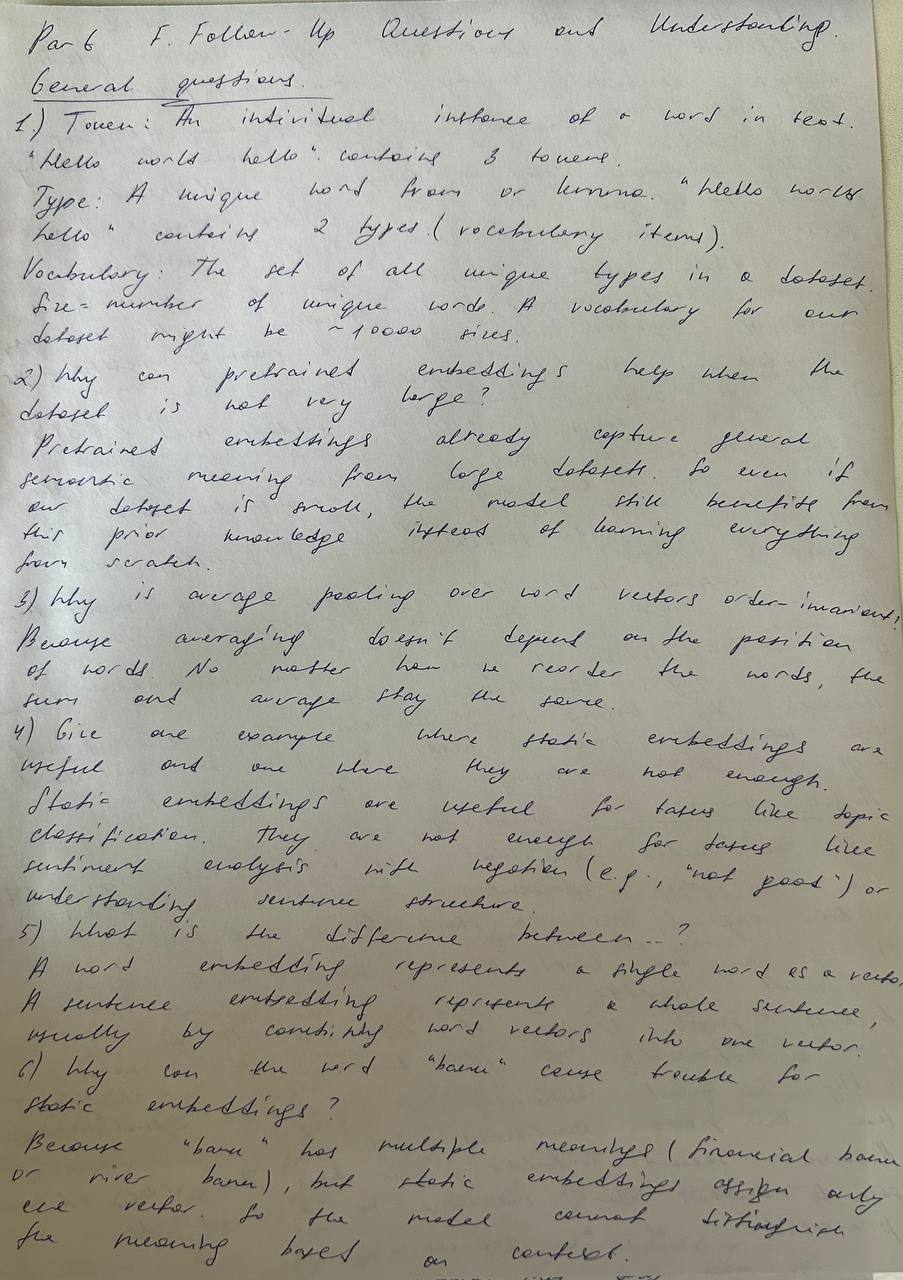

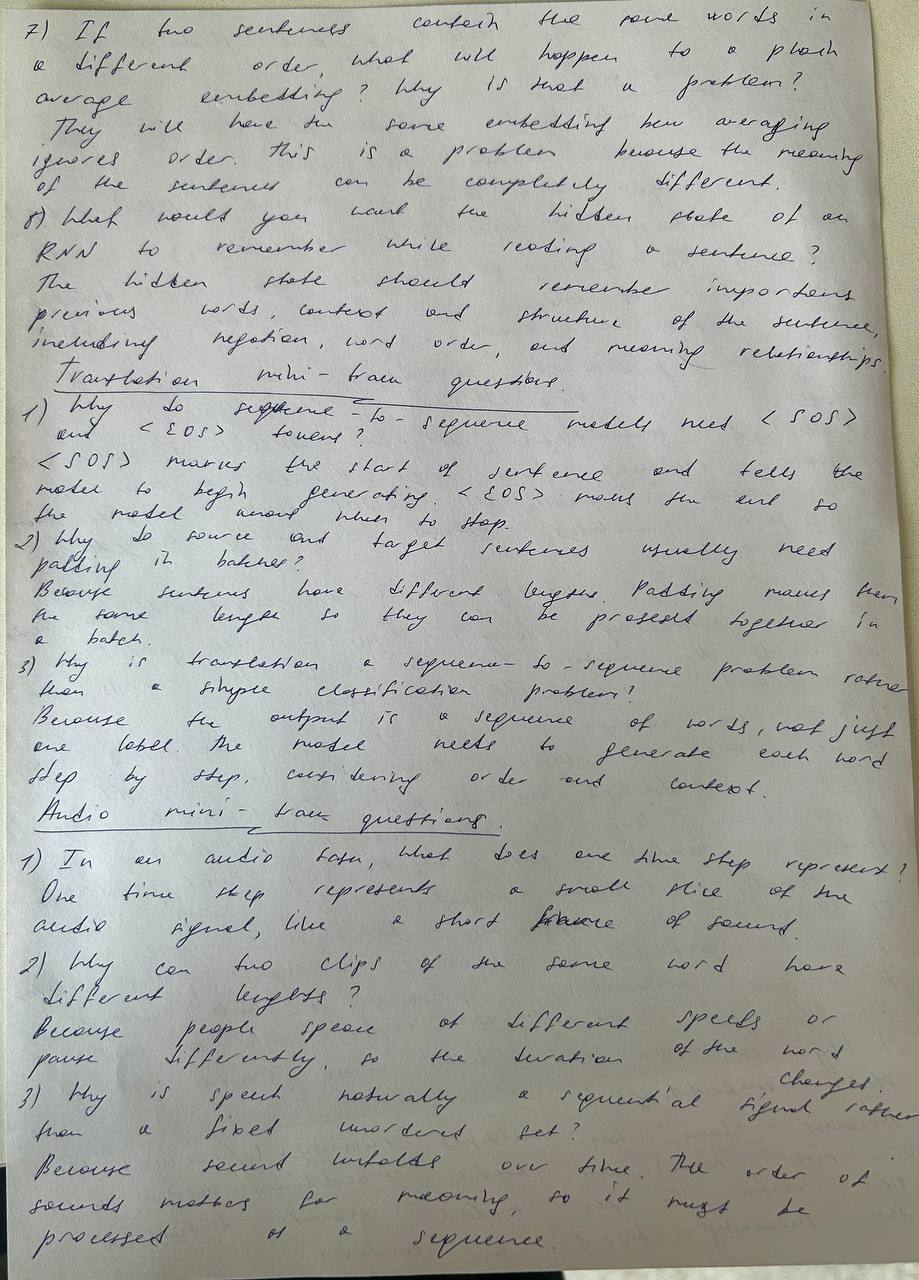

### Q1: What is the difference between a token, a type, and a vocabulary?

**Token**: An individual instance of a word in text. "Hello world hello" contains 3 tokens ("Hello", "world", "hello").

**Type**: A unique word form or lemma. "Hello world hello" contains 2 types: {"hello", "world"}. Types are also called vocabulary items.

**Vocabulary**: The set of all unique types in a dataset. Size = number of unique words. A vocabulary for our dataset might be {the, good, movie, not, ...} with size ~10,000.

Simple formula: Total tokens ÷ Unique types = Average repetition of words in corpus.

### Q2: Why can pretrained embeddings help when the dataset is not very large?

Pretrained embeddings (Word2Vec, GloVe, spaCy) are trained on **billions of words** from diverse text. They already encode semantic relationships: "king" is near "queen", "good" is near "excellent".

Benefits for small datasets:
- **Transfer learning**: Knowledge from large corpus applies to your task without retraining
- **Fewer parameters to learn**: You only train a classifier on top; embeddings are fixed
- **Better generalization**: Rare words can be handled if semantically similar words are in the pretrained vocabulary
- **Faster convergence**: Training a classifier on fixed embeddings converges quickly

Without pretraining, a small dataset wouldn't have enough examples to learn good word representations from scratch.

### Q3: Why is average pooling over word vectors order-invariant?

Because **averaging (addition then division) is commutative**:

$$\frac{v_1 + v_2 + v_3}{3} = \frac{v_3 + v_1 + v_2}{3} = \frac{v_2 + v_3 + v_1}{3}$$

Order doesn't affect the sum, so it doesn't affect the average. This is mathematically elegant but linguistically problematic:
- "I love you" and "you love I" (nonsensical in English) produce identical vectors
- Subject-verb-object order is erased
- Position-dependent phenomena (negation scope, modifier attachment) are lost

### Q4: Give one example where static embeddings are useful and one where they are not enough.

**Useful**: Finding similar documents or clustering by topic.
- Document 1: "I love coffee"
- Document 2: "I enjoy tea and coffee"
Because both mention "coffee", their averaged vectors are similar, and we can cluster or rank them together. Sentiment subtlety doesn't matter; topic similarity is sufficient.

**Not enough**: Sentiment classification with negation.
- "This is good" → positive
- "This is not good" → negative
Both share "good", so averaged vectors are nearly identical. But they have opposite sentiments. Static averaging can't represent "good" vs. "¬good".

### Q5: What is the difference between a word embedding and a sentence embedding?

**Word embedding**: A fixed-size vector representing a single word (e.g., "dog" → 300-dim vector). Learned from co-occurrence patterns; context-independent (in static models).

**Sentence embedding**: A fixed-size vector representing an entire phrase or sentence. Must combine word embeddings somehow:
- Simple: Average of word vectors (what we used) ← fast but loses order
- Better: Doc2Vec, Sentence-BERT ← trained on sentence pairs
- Best: RNN/Transformer hidden state ← context-dependent

A sentence embedding should capture meaning at a higher level than words.

### Q6: Why can the word "bank" cause trouble for static embeddings?

"Bank" has multiple senses:
- Financial institution: "deposit money in a bank"
- Riverbank: "walk along the bank"
- To tilt: "bank the aircraft"

A static embedding assigns **one vector** to "bank", averaging across all senses. When you see "bank", you can't tell which sense is meant.

Comparison:
- Static embeddings: "bank" has one fixed vector (polysemy problem)
- Contextualized embeddings (BERT, GPT): "bank" gets different vectors based on context

This is **polysemy**: one word, multiple meanings. It's a fundamental limitation of static representations.

### Q7: If two sentences contain the same words in different order, what happens to a plain average embedding? Why is that a problem?

**What happens**: They get ***identical average embeddings***.

Example:
- "I love you" → average([I, love, you])
- "you love I" → average([you, love, I])
- These are mathematically equal (addition is commutative)

**Why it's a problem**:
- **Meaning changes**: Different word orders convey different meanings (or nonsense, as in "you love I")
- **Grammar is lost**: SVO (English) vs. SOV (Japanese) structures disappear
- **Syntax can't be represented**: "not" modifies the next word, but averaging doesn't capture "scope"
- **Dependencies are destroyed**: Subject-verb agreement and other relationships vanish

Language is sequential; averaging fundamentally cannot preserve sequence information.

### Q8: What would you want the hidden state of an RNN to remember while reading a sentence?

An RNN hidden state should track:

1. **Syntactic structure**: Are we in a clause, question, or statement? Is the subject singular/plural? What verb tense was used?
2. **Dependency relationships**: Who is doing what to whom? What noun phrases are present?
3. **Negation and modifiers**: Has negation been applied? Are intensifiers present ("very", "extremely")?
4. **Open dependencies**: What questions are unresolved? "The dog that...was...did what?"
5. **Semantic context**: What topics have been discussed? What entities are relevant?

Unlike simple averaging, the RNN's hidden state is **position-dependent**: $h_t = f(x_t, h_{t-1})$ depends on reading order. After "The dog bites", $h_3$ knows "dog" is the agent and "bites" is the action. After "The dog was bitten", $h_3$ knows the structure is passive. This positional sensitivity lets RNNs capture what averaging cannot.

---

## Translation Mini-Track Questions

### Q9: Why do sequence-to-sequence models need <SOS> and <EOS> tokens?

**<SOS> (Start Of Sequence)**:
- Signals to the decoder "start generating"
- Without it, the decoder doesn't know when generation begins
- Helps the model learn that the first generated token has a special role

**<EOS> (End Of Sequence)**:
- Signals "stop generating" / "sequence is complete"
- Lets the decoder learn to stop at the right time (not generate forever)
- Marks the boundary between sequences

Together, they frame the input and output, giving the model explicit signals about sequence boundaries. Without them, the model wouldn't know where sequences start/end.

### Q10: Why do source and target sentences usually need padding in batches?

**Variable lengths**: Different sentences have different lengths. A batch might contain:
- "good morning" (2 tokens)
- "where is the station" (5 tokens)

**Why padding**: Neural networks rely on fixed tensor shapes. To batch these together:
- Pad "good morning" to length 5: ["<SOS>", "good", "morning", "<EOS>", "<PAD>"]
- No padding needed for 5-token sentence: ["<SOS>", "where", "is", "the", "station", "<EOS>"]
 (Actually this is 6, so both get padded to 6)

**Attention masking**: The model learns to ignore <PAD> tokens via attention masks, so they don't affect the computation. But they're necessary for computational efficiency (matrix operations on fixed-size batches are much faster).

### Q11: Why is translation a sequence-to-sequence problem rather than a simple classification problem?

**Classification**: Fixed number of classes (e.g., sentiment: positive/negative). Input → single output label.

**Sequence-to-sequence**: Variable-length input → variable-length output.
- Input: "hello" (1 word) or "where is the train station" (6 words)
- Output: "salem" (1 word) or "poyezd vokzaly qaida" (variable words)

Translation must:
1. Understand variable-length input (no fixed input size like in classification)
2. Generate variable-length output (not a single label)
3. Align words across languages (some words combine, some split, some reorder)
4. Handle many-to-many mappings ("do you" → one target verb, or vice versa)

This is fundamentally different from classification. It requires an encoder-decoder architecture that can read and then generate arbitrary-length sequences.